# 11 — PDE solvers

Fokker–Planck, HJB, Poisson.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110


## Pure-diffusion Fokker–Planck

$\partial_t m = \tfrac12 \partial_{xx} m$ with Gaussian initial density should remain centred and approximately Gaussian.

In [2]:
res = opt.fokker_planck_constant(
    mu=0.0, sigma_sq=1.0, init_sigma=1.0,
    x_min=-8.0, x_max=8.0, n_x=401,
    t_horizon=0.5, n_t=8000,
)
x = np.array(res['x_grid'])
t = np.array(res['time_grid'])
nx = res['n_x']; nt = res['n_t']
M = np.array(res['density']).reshape(nt + 1, nx)
print('total mass at t=0:',  np.trapezoid(M[0], x))
print('total mass at t=T:',  np.trapezoid(M[-1], x))
print('mean   at t=T:',      np.trapezoid(x * M[-1], x))


total mass at t=0: 1.0000000000000002
total mass at t=T: 0.9999999998667097
mean   at t=T: -1.6653345369377348e-16


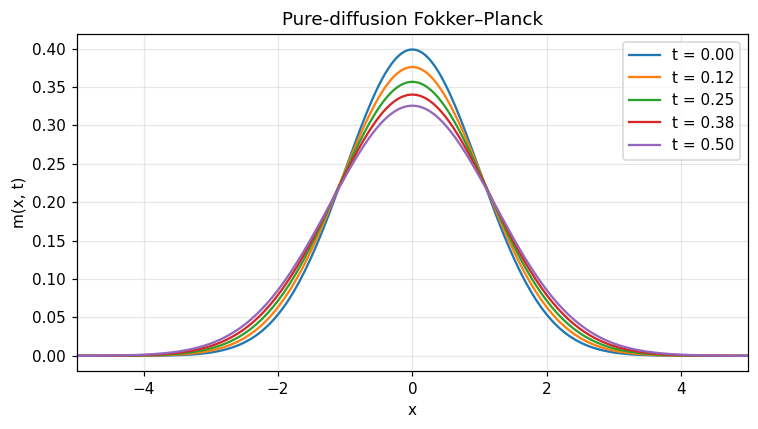

In [3]:
fig, ax = plt.subplots()
for k in [0, nt // 4, nt // 2, 3 * nt // 4, nt]:
    ax.plot(x, M[k], label=f't = {t[k]:.2f}')
ax.set_xlim(-5, 5); ax.set_xlabel('x'); ax.set_ylabel('m(x, t)')
ax.set_title('Pure-diffusion Fokker–Planck'); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()


## 2-D Poisson eigenfunction

$-\Delta u = 2\pi^2 \sin(\pi x)\sin(\pi y)$ on the unit square with zero Dirichlet boundary admits the exact solution $u(x,y) = \sin(\pi x)\sin(\pi y)$.

In [4]:
n = 65
xs = np.linspace(0, 1, n); ys = np.linspace(0, 1, n)
X, Y = np.meshgrid(xs, ys, indexing='ij')
F = 2 * np.pi ** 2 * np.sin(np.pi * X) * np.sin(np.pi * Y)
res = opt.poisson_2d_zero_boundary(F.flatten().tolist(), n, n)
U = np.array(res['u']).reshape(n, n)
U_exact = np.sin(np.pi * X) * np.sin(np.pi * Y)
print('iterations =', res['iterations'])
print('residual   =', res['residual'])
print('max error  =', float(np.max(np.abs(U - U_exact))))


iterations = 690
residual   = 9.865621268811964e-07
max error  = 0.00013249923574043532


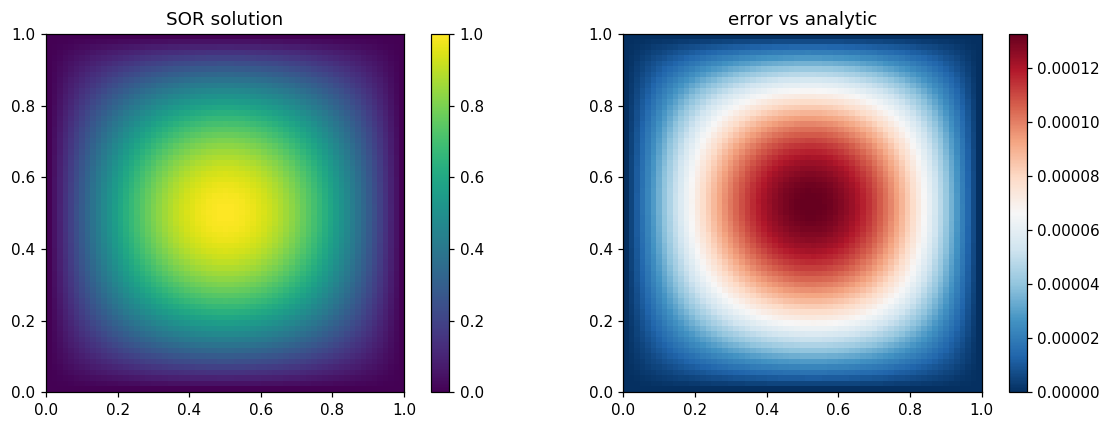

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(U.T, origin='lower', extent=(0, 1, 0, 1), cmap='viridis')
axes[0].set_title('SOR solution'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow((U - U_exact).T, origin='lower', extent=(0, 1, 0, 1), cmap='RdBu_r')
axes[1].set_title('error vs analytic'); plt.colorbar(im1, ax=axes[1])
fig.tight_layout(); plt.show()


## 2-D HJB with quadratic terminal

Heat-only relaxation ($H = 0$, σ² > 0) preserves a constant value, while a quadratic terminal $g(x) = ½(x²+y²)$ smooths.

In [6]:
res = opt.hjb_quadratic_2d(n_per_dim=21, x_min=-1.0, x_max=1.0,
                            n_t=200, t_horizon=0.2, sigma_sq=0.1)
ax_x = np.array(res['axis']); npd = res['n_per_dim']
V = np.array(res['value']).reshape(npd, npd)
print('V(0,0)   =', V[npd // 2, npd // 2])
print('V(±1,±1) =', V[0, 0], V[-1, -1])


V(0,0)   = 0.018239022846662144
V(±1,±1) = 0.8159229411398733 0.8159229411398735


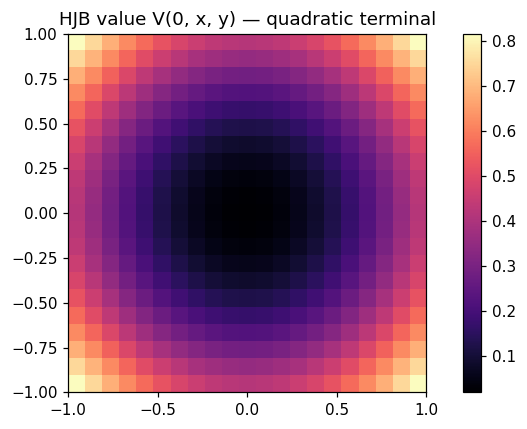

In [7]:
fig, ax = plt.subplots()
im = ax.imshow(V.T, origin='lower', extent=(-1, 1, -1, 1), cmap='magma')
ax.set_title('HJB value V(0, x, y) — quadratic terminal')
plt.colorbar(im, ax=ax)
fig.tight_layout(); plt.show()


**Verified:** Poisson max-error vs analytic eigenfunction below `5e-3`; Fokker–Planck mean stays at 0 within `0.05`.